# Bark Beetle · Temperature · Posek — Monthly View
Set `ODSEK_ID` and `YEAR` below, then run all cells.

In [16]:
# ── Configuration ─────────────────────────────────────────────────────────
ODSEK_ID = "31027"   # any odsek_id present in posek_processed.csv
YEAR     = 2008       # 2007 – 2025

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

ROOT     = Path(".").resolve().parent
DATA     = ROOT / "data"
BB_PATH  = DATA / "synthetic"  / "bark_beetle_by_odsek.csv"
POS_PATH = DATA / "processed"  / "posek_processed.csv"
STA_PATH = DATA / "processed"  / "najblizji_odseki_postaje.csv"
WEA_PATH = DATA / "raw" / "ARSO" / "vreme.csv"

MONTHS     = list(range(1, 13))
MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

In [18]:
# ── 1. Bark beetle counts ──────────────────────────────────────────────────
bb = pd.read_csv(BB_PATH, low_memory=False)
bb["leto_mesec"] = bb["leto_mesec"].astype(str)
bb["odsek_id"]   = bb["odsek_id"].astype(str)

bb_year = bb[
    (bb["odsek_id"] == str(ODSEK_ID)) &
    (bb["leto_mesec"].str.startswith(str(YEAR)))
].copy()
bb_year["mesec"] = bb_year["leto_mesec"].str.split("-").str[1].astype(int)
bb_year = bb_year.set_index("mesec").reindex(MONTHS)

if bb_year["bark_beetle_count"].isna().all():
    raise ValueError(f"No bark beetle data for odsek_id={ODSEK_ID!r} in year {YEAR}.")
print(f"Bark beetle data: {bb_year['bark_beetle_count'].notna().sum()} months found")

Bark beetle data: 12 months found


In [19]:
# ── 2. Posek (wood cut) ────────────────────────────────────────────────────
posek_raw = pd.read_csv(POS_PATH, low_memory=False)
posek_raw["odsek"]   = posek_raw["odsek"].astype(str)
posek_raw["kubikov"] = pd.to_numeric(posek_raw["kubikov"], errors="coerce").fillna(0.0)

posek_sel = posek_raw[
    (posek_raw["odsek"] == str(ODSEK_ID)) &
    (posek_raw["leto"]  == YEAR)
].groupby("mesec")["kubikov"].sum().reindex(MONTHS, fill_value=0.0)

print(f"Posek: {(posek_sel > 0).sum()} months with cutting, total {posek_sel.sum():.1f} m³")

Posek: 0 months with cutting, total 0.0 m³


In [20]:
# ── 3. Weather — find nearest station, aggregate to monthly ───────────────
sta = pd.read_csv(STA_PATH, low_memory=False)
sta["odsek_id"] = sta["odsek_id"].astype(str)
sta = sta.set_index("odsek_id")

station_id = None
if str(ODSEK_ID) in sta.index:
    row = sta.loc[str(ODSEK_ID)]
    for col in [f"station_23_{YEAR}", f"station_123_{YEAR}", "station_23", "station_123"]:
        val = row.get(col)
        if pd.notna(val):
            station_id = int(val)
            print(f"Using station {station_id} ({col})")
            break

if station_id is None:
    print("No station found — using global mean temperature.")

vreme = pd.read_csv(WEA_PATH, usecols=[0,1,2,3,4], low_memory=False)
vreme.columns = ["station_id","datum","avg_temp","max_temp","min_temp"]
for c in ["avg_temp","max_temp","min_temp"]:
    vreme[c] = pd.to_numeric(vreme[c], errors="coerce")
vreme["datum"] = pd.to_datetime(vreme["datum"], errors="coerce")
vreme = vreme.dropna(subset=["datum"])
vreme = vreme[vreme["datum"].dt.year == YEAR]

vreme_sel = vreme[vreme["station_id"] == station_id] if station_id is not None else vreme
vreme_monthly = (
    vreme_sel.groupby(vreme_sel["datum"].dt.month)
    .agg(avg=("avg_temp","mean"), hi=("max_temp","mean"), lo=("min_temp","mean"))
    .reindex(MONTHS)
)
print(f"Temperature: {vreme_monthly['avg'].notna().sum()} months with readings")

Using station 2482 (station_23_2008)
Temperature: 10 months with readings


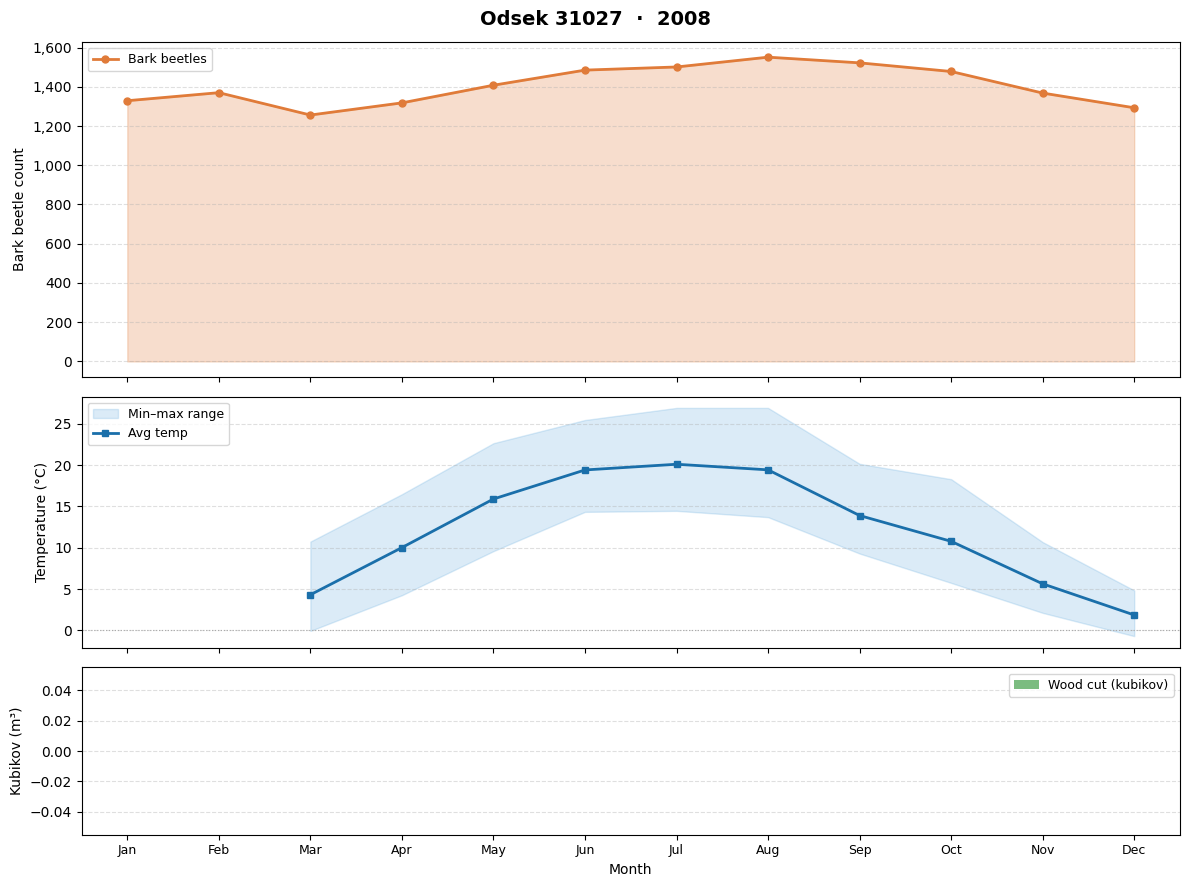

In [21]:
# ── 4. Plot: single odsek, single year ────────────────────────────────────
fig, axes = plt.subplots(
    3, 1, figsize=(12, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1.5, 1]},
)
fig.suptitle(f"Odsek {ODSEK_ID}  ·  {YEAR}", fontsize=14, fontweight="bold", y=0.98)
x = np.arange(1, 13)

# panel 1: bark beetles
ax1 = axes[0]
beetle_vals = bb_year["bark_beetle_count"].values.astype(float)
ax1.fill_between(x, beetle_vals, alpha=0.25, color="#e07b39")
ax1.plot(x, beetle_vals, color="#e07b39", linewidth=2.0, marker="o", markersize=5, label="Bark beetles")
ax1.set_ylabel("Bark beetle count", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(loc="upper left", fontsize=9)
ax1.set_xlim(0.5, 12.5)

# panel 2: temperature
ax2 = axes[1]
avg_t = vreme_monthly["avg"].values.astype(float)
hi_t  = vreme_monthly["hi"].values.astype(float)
lo_t  = vreme_monthly["lo"].values.astype(float)
ax2.fill_between(x, lo_t, hi_t, alpha=0.20, color="#4c9ed9", label="Min–max range")
ax2.plot(x, avg_t, color="#1a6faa", linewidth=2.0, marker="s", markersize=5, label="Avg temp")
ax2.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle=":")
ax2.set_ylabel("Temperature (°C)", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(loc="upper left", fontsize=9)

# panel 3: wood cut
ax3 = axes[2]
kub  = posek_sel.values.astype(float)
bars = ax3.bar(x, kub, color="#5aab61", alpha=0.8, width=0.6, label="Wood cut (kubikov)")
ax3.set_ylabel("Kubikov (m³)", fontsize=10)
ax3.set_xlabel("Month", fontsize=10)
ax3.grid(axis="y", linestyle="--", alpha=0.4)
ax3.legend(loc="upper right", fontsize=9)
ax3.set_xticks(x)
ax3.set_xticklabels(MONTH_ABBR, fontsize=9)
for bar, val in zip(bars, kub):
    if val > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + kub.max()*0.02,
                 f"{val:.0f}", ha="center", va="bottom", fontsize=7, color="#2d6e33")

plt.tight_layout()
plt.show()

---
## 10 Random Odseks — Full Time Series (2007–2025)
Orange = bark beetle population &nbsp;·&nbsp; Green stems = posek events (height ∝ kubikov)

Chosen odseks: ['01A06A', '05066B', '05106A', '16012A', '16109A', '16143C', '19129', '25042B', '35028', '38143']


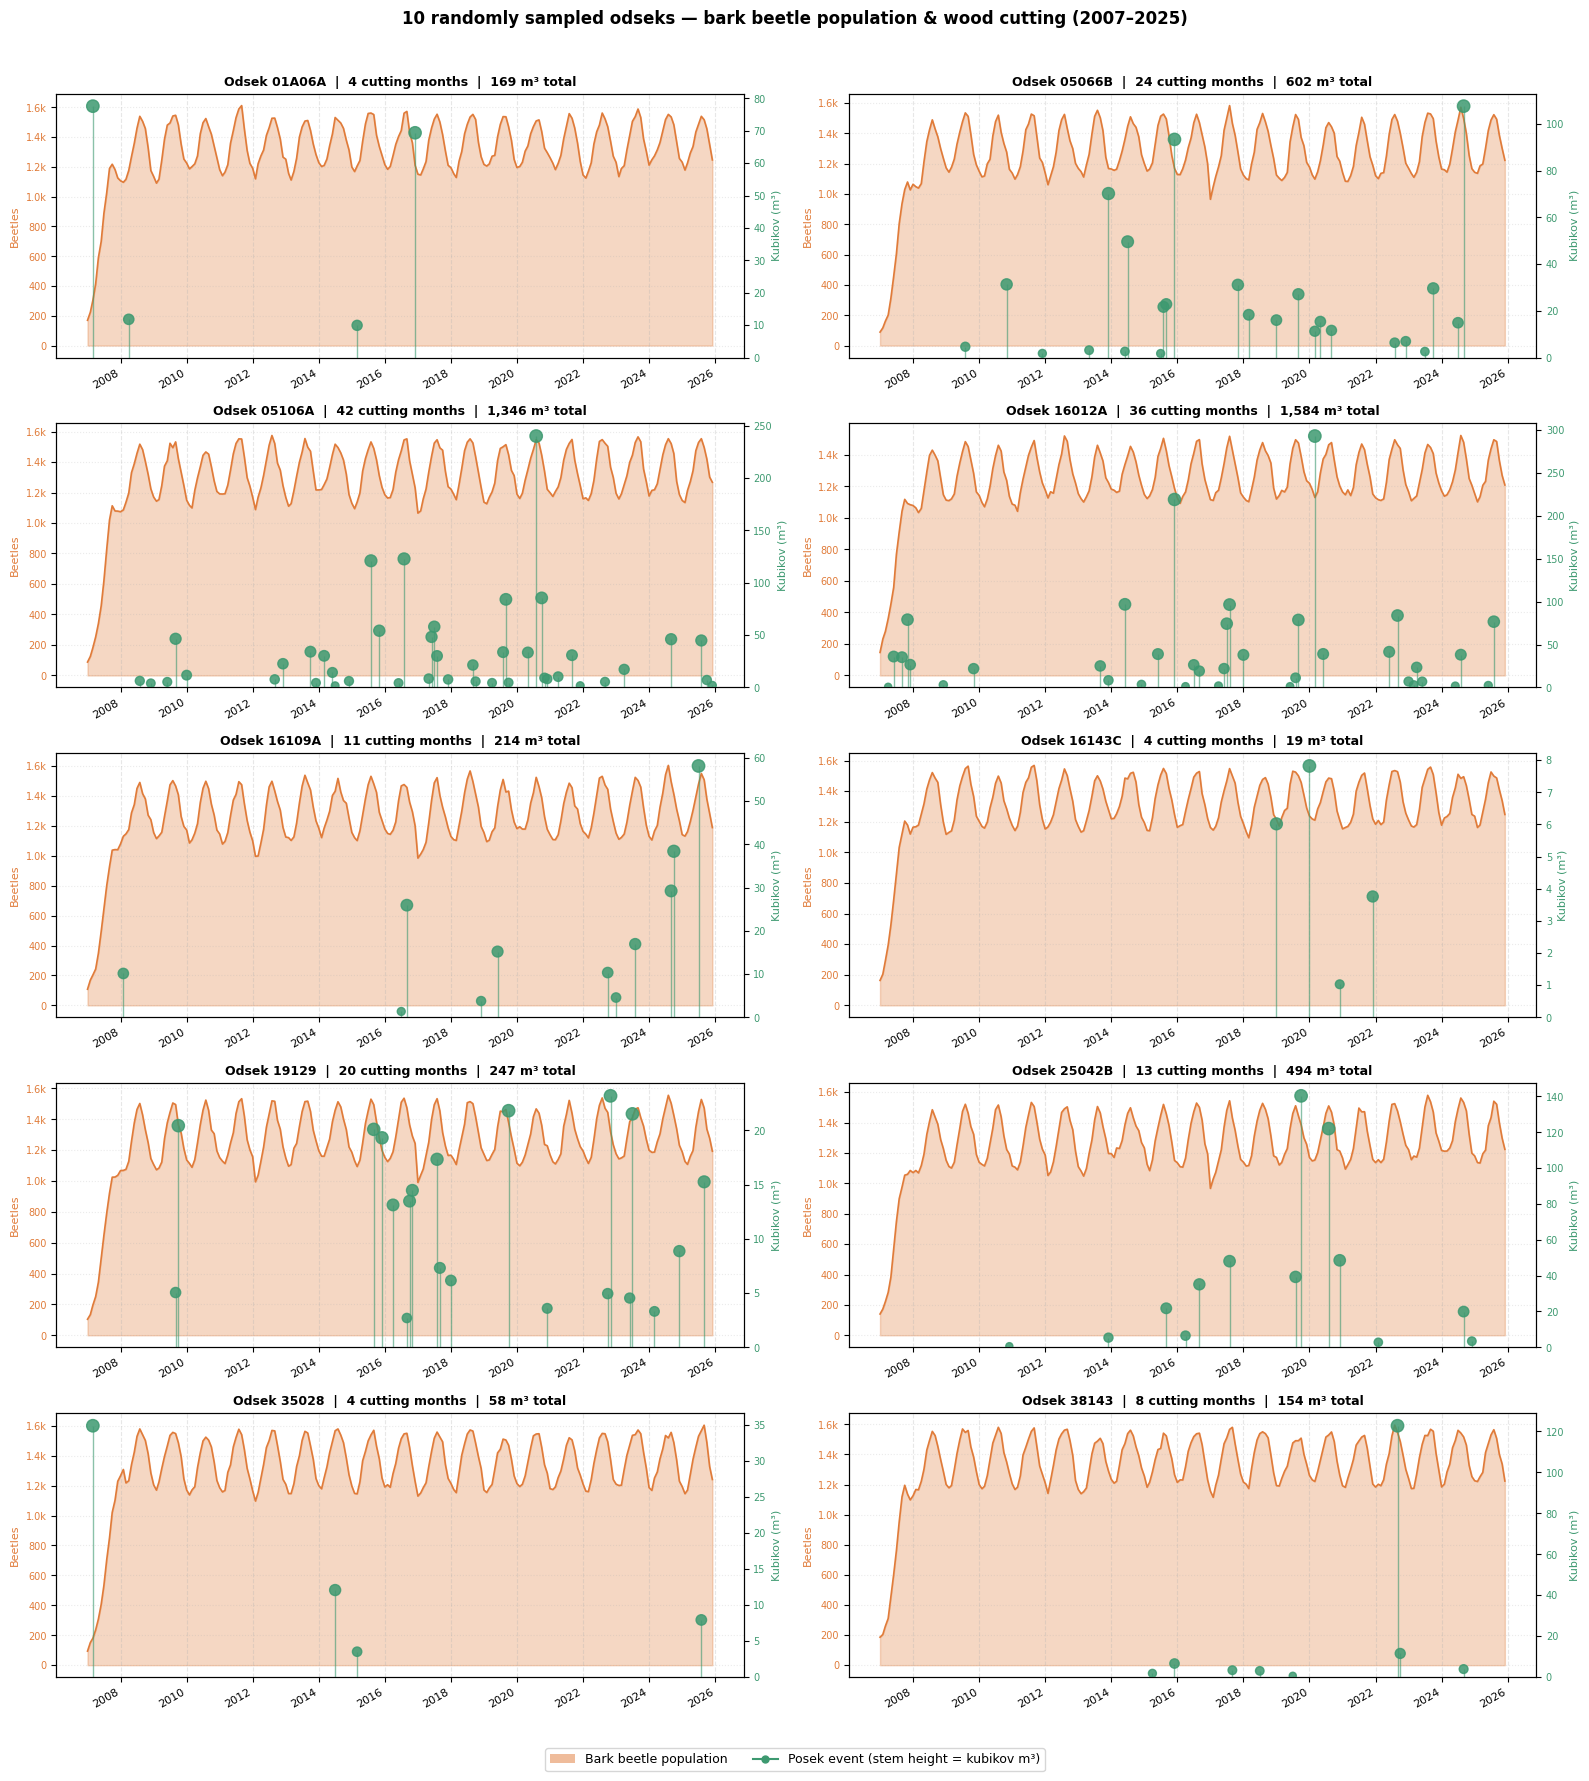

In [22]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

N_RANDOM = 10  # how many odseks to draw
RNG_SEED = 0   # change for a different random draw

# ── load data ─────────────────────────────────────────────────────────────
bb_all = pd.read_csv(BB_PATH, low_memory=False)
bb_all["odsek_id"]   = bb_all["odsek_id"].astype(str)
bb_all["leto_mesec"] = bb_all["leto_mesec"].astype(str)

pos_all = pd.read_csv(POS_PATH, low_memory=False)
pos_all["odsek"]   = pos_all["odsek"].astype(str)
pos_all["kubikov"] = pd.to_numeric(pos_all["kubikov"], errors="coerce").fillna(0.0)
pos_all["leto"]    = pos_all["leto"].astype(int)
pos_all["mesec"]   = pos_all["mesec"].astype(int)
pos_all["leto_mesec"] = pos_all["leto"].astype(str) + "-" + pos_all["mesec"].astype(str).str.zfill(2)

# ── pick 10 odseks that appear in both datasets with at least one posek ───
candidates = list(
    set(pos_all[pos_all["kubikov"] > 0]["odsek"].unique()) &
    set(bb_all["odsek_id"].unique())
)
rng    = np.random.default_rng(RNG_SEED)
chosen = sorted(rng.choice(candidates, size=min(N_RANDOM, len(candidates)), replace=False).tolist())
print("Chosen odseks:", chosen)

# ── full monthly time axis ─────────────────────────────────────────────────
all_periods = pd.period_range("2007-01", "2025-12", freq="M")
all_dates   = all_periods.to_timestamp()
all_lm      = [str(p) for p in all_periods]

# ── aggregate posek monthly ────────────────────────────────────────────────
posek_agg = (
    pos_all[pos_all["odsek"].isin(chosen)]
    .groupby(["odsek", "leto_mesec"], as_index=False)["kubikov"]
    .sum()
)
posek_agg["leto_mesec"] = posek_agg["leto_mesec"].astype(str)
bb_chosen = bb_all[bb_all["odsek_id"].isin(chosen)].copy()

# ── 5 rows × 2 cols, twin y-axis per panel ────────────────────────────────
ncols = 2
nrows = (N_RANDOM + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharey=False)
axes_flat  = axes.flatten()

for ax_idx, odsek_id in enumerate(chosen):
    ax  = axes_flat[ax_idx]
    ax2 = ax.twinx()

    # beetles
    od_bb = (
        bb_chosen[bb_chosen["odsek_id"] == odsek_id]
        .set_index("leto_mesec")
        .reindex(all_lm)["bark_beetle_count"]
        .values.astype(float)
    )
    ax.fill_between(all_dates, od_bb, alpha=0.30, color="#e07b39")
    ax.plot(all_dates, od_bb, color="#e07b39", linewidth=1.2)
    ax.set_ylabel("Beetles", fontsize=8, color="#e07b39")
    ax.tick_params(axis="y", labelcolor="#e07b39", labelsize=7)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v/1e3:.1f}k" if v >= 1000 else f"{v:.0f}")
    )

    # posek stems
    od_posek = (
        posek_agg[posek_agg["odsek"] == odsek_id]
        .set_index("leto_mesec")
        .reindex(all_lm)["kubikov"]
        .fillna(0.0)
        .values.astype(float)
    )
    nz_mask  = od_posek > 0
    nz_dates = all_dates[nz_mask]
    nz_kub   = od_posek[nz_mask]
    if nz_kub.size > 0:
        sizes = 20 + 60 * (np.log1p(nz_kub) / np.log1p(nz_kub.max()))
        ax2.vlines(nz_dates, 0, nz_kub, colors="#3d9970", linewidth=1.0, alpha=0.6)
        ax2.scatter(nz_dates, nz_kub, s=sizes, color="#3d9970", alpha=0.85, zorder=3)
    ax2.set_ylabel("Kubikov (m³)", fontsize=8, color="#3d9970")
    ax2.tick_params(axis="y", labelcolor="#3d9970", labelsize=7)
    ax2.set_ylim(bottom=0)

    ax.set_title(
        f"Odsek {odsek_id}  |  {nz_mask.sum()} cutting months  |  {od_posek.sum():,.0f} m³ total",
        fontsize=9, fontweight="bold",
    )
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", linestyle=":",  alpha=0.25)
    ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(2))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), fontsize=8, rotation=30, ha="right")

for i in range(len(chosen), len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.legend(
    handles=[
        Patch(facecolor="#e07b39", alpha=0.5, label="Bark beetle population"),
        Line2D([0],[0], color="#3d9970", linewidth=1.5, marker="o",
               markersize=5, label="Posek event (stem height = kubikov m³)"),
    ],
    loc="lower center", ncol=2, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.0),
)
fig.suptitle(
    f"{N_RANDOM} randomly sampled odseks — bark beetle population & wood cutting (2007–2025)",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()